In [78]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [79]:
import kagglehub
import pandas as pd
import os

In [80]:
path = kagglehub.dataset_download("asaniczka/uk-optimal-product-price-prediction")
print("Path to dataset files:", path)

files = os.listdir(path)
print("Arquivos disponíveis:", files)

csv_file = [f for f in files if f.endswith(".csv")][0]
file_path = os.path.join(path, csv_file)

df = pd.read_csv(file_path)


Path to dataset files: C:\Users\leolo\.cache\kagglehub\datasets\asaniczka\uk-optimal-product-price-prediction\versions\3
Arquivos disponíveis: ['amz_uk_price_prediction_dataset.csv']


In [81]:
print(df.head())


   uid        asin                                              title  stars  \
0    1  B09B96TG33  Echo Dot (5th generation, 2022 release) | Big ...    4.7   
1    2  B01HTH3C8S  Anker Soundcore mini, Super-Portable Bluetooth...    4.7   
2    3  B09B8YWXDF  Echo Dot (5th generation, 2022 release) | Big ...    4.7   
3    4  B09B8T5VGV  Echo Dot with clock (5th generation, 2022 rele...    4.7   
4    5  B09WX6QD65  Introducing Echo Pop | Full sound compact Wi-F...    4.6   

   reviews  price  isBestSeller  boughtInLastMonth        category  
0    15308  21.99         False                  0  Hi-Fi Speakers  
1    98099  23.99          True                  0  Hi-Fi Speakers  
2    15308  21.99         False                  0  Hi-Fi Speakers  
3     7205  31.99         False                  0  Hi-Fi Speakers  
4     1881  17.99         False                  0  Hi-Fi Speakers  


In [82]:
print(df.columns)

Index(['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller',
       'boughtInLastMonth', 'category'],
      dtype='object')


In [83]:
##Tabela de frequência da categoria

frequency_table = df['category'].value_counts()
print(frequency_table)

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
                                           ...  
Alexa Built-In Devices                       107
Motorbike Chassis                            107
Plugs                                        107
Smart Home Security & Lighting               104
Smart Speakers                                54
Name: count, Length: 296, dtype: int64


In [84]:
# 'Top 5 categorias mais listadas
top_5_categorys = frequency_table.head(5)
print(top_5_categorys)

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64


In [85]:
import matplotlib.pyplot as plt

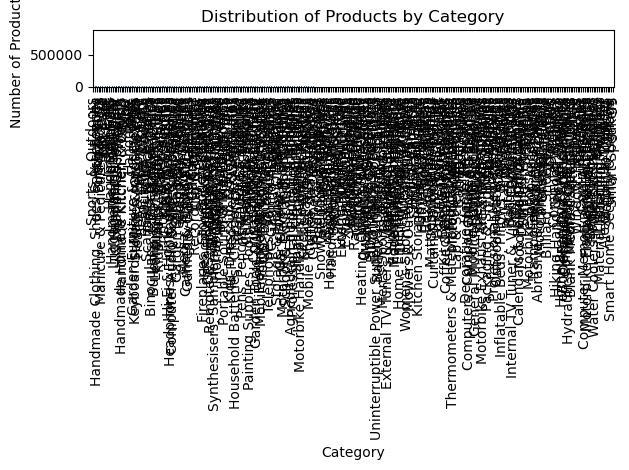

In [86]:
category_counts = df['category'].value_counts()

plt.figure()
category_counts.plot(kind='bar')
plt.title('Distribution of Products by Category')
plt.xlabel('Category')
plt.ylabel('Number of Products')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Number of Products')

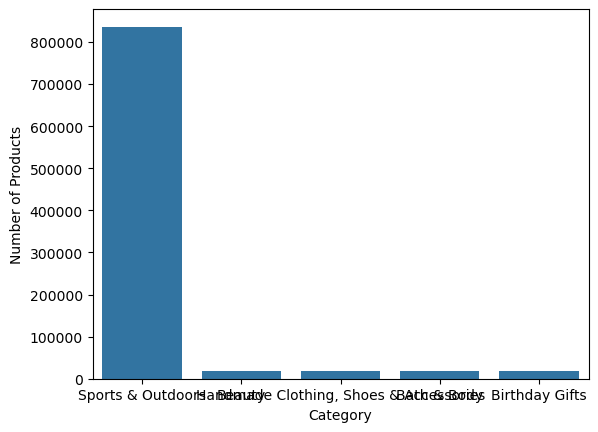

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt

category_counts = df['category'].value_counts()
top_5_categorys = category_counts.head(5)


sns.barplot(x=top_5_categorys.index,
            y=top_5_categorys.values)

plt.xlabel('Category')
plt.ylabel('Number of Products')

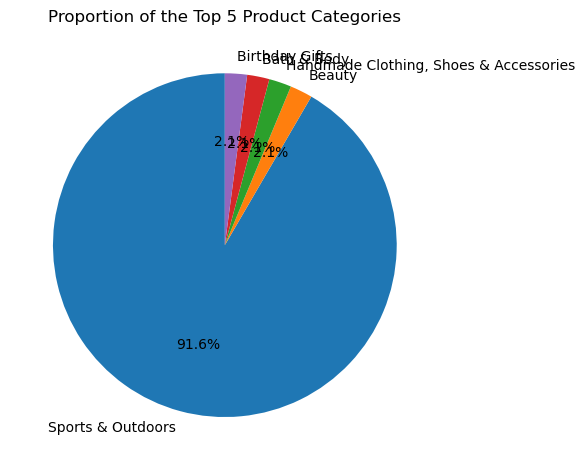

In [88]:
plt.figure()
top_5_categorys.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Proportion of the Top 5 Product Categories')
plt.ylabel('')  
plt.tight_layout()
plt.show()

In [89]:
df.columns

Index(['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller',
       'boughtInLastMonth', 'category'],
      dtype='object')

In [90]:
df.columns = df.columns.str.strip()

In [91]:
avg_price = df["price"].mean()
mode_price = df["price"].mode()[0]
median_price = df["price"].median()

avg_price, mode_price, median_price 


(np.float64(89.24380943923661), np.float64(9.99), 19.09)

In [92]:
##  The large difference between the average and the other measures indicates the presence of high-priced products that distort the average.

In [93]:
var_price = df["price"].var()
std_price = df["price"].std()
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

avg_price, std_price, IQR

(np.float64(89.24380943923661), 345.60886175352226, np.float64(36.0))

In [94]:
## The variance and standard deviation indicate high price dispersion.
## The range shows a significant difference between the cheapest and most expensive products.
## The interquartile range confirms that, although most products are concentrated in lower price ranges, there are extreme values that considerably increase variability.

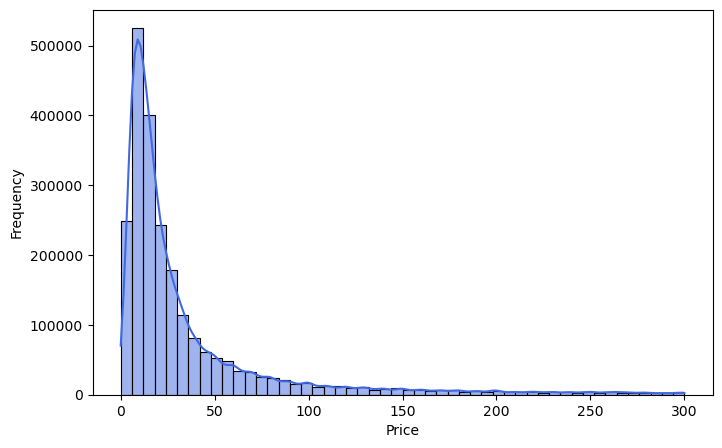

In [95]:
df.columns = df.columns.str.strip()

filtered_prices = df[df["price"] <300]["price"]

plt.figure(figsize=(8,5))
sns.histplot(filtered_prices, bins=50, kde=True, color='royalblue')
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

<Axes: ylabel='price'>

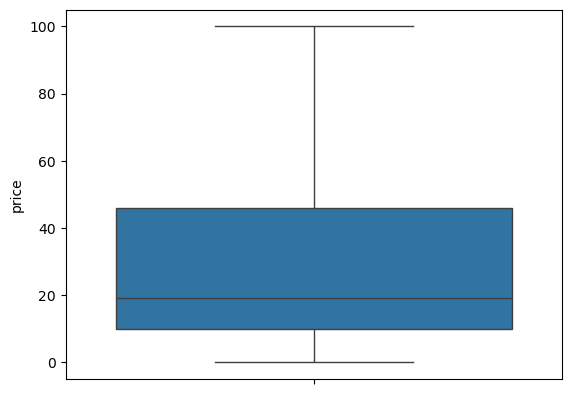

In [96]:
df.columns = df.columns.str.strip()

sns.boxplot(df["price"], showfliers=False)

In [97]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR
lower_limit = Q1 - 1.5 * IQR

outliers = df[(df["price"] > upper_limit) | (df["price"] < lower_limit)]
len(outliers)

327688

In [98]:
df.columns

Index(['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller',
       'boughtInLastMonth', 'category'],
      dtype='object')

In [99]:
df["stars"].value_counts()


stars
0.0    1225641
4.5     151577
4.6     136995
4.4     136165
5.0     128492
4.3     112564
4.7      94566
4.2      86871
4.0      66089
4.1      65115
4.8      41858
3.9      36555
3.8      27876
3.7      21137
3.6      16219
3.5      14673
3.0      12819
4.9      11081
3.4      10355
1.0       8484
3.3       8269
3.2       5771
3.1       4679
2.0       3901
2.9       3341
2.8       2306
2.7       2104
2.5       2103
2.6       1579
2.4       1060
2.3        734
2.2        602
2.1        540
1.5        404
1.9        300
1.8        249
1.7        177
1.4        149
1.6        147
1.3         78
1.2         23
1.1          3
Name: count, dtype: int64

In [100]:
df["stars"].describe()


count    2.443651e+06
mean     2.152836e+00
std      2.194865e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      4.400000e+00
max      5.000000e+00
Name: stars, dtype: float64

In [101]:
valids_ratings = df[df["stars"] > 0]["stars"]

ratings_validos = valids_ratings.dropna()
ratings_validos.describe()

count    1.218010e+06
mean     4.319161e+00
std      5.552868e-01
min      1.000000e+00
25%      4.100000e+00
50%      4.400000e+00
75%      4.600000e+00
max      5.000000e+00
Name: stars, dtype: float64

In [102]:
avg_raiting = valids_ratings.mean() 
median_raiting = valids_ratings.median()
mode_raiting = valids_ratings.mode().iloc[0]

avg_raiting, median_raiting, mode_raiting



(np.float64(4.319160762226911), 4.4, np.float64(4.5))

In [103]:
##The average rating is 4.3, the mean is 4.4, and the mode is 4.5. This means that product reviews are generally good.

In [104]:
var_raiting = valids_ratings.var() 
std_raiting = valids_ratings.std()
Q1 = valids_ratings.quantile(0.25)
Q3 = valids_ratings.quantile(0.75)
IQR = Q3 - Q1

avg_price, std_price, IQR


(np.float64(89.24380943923661), 345.60886175352226, np.float64(0.5))

In [105]:
##Since the standard deviation is much higher than the variance, there is evidence of outliers.
##The IQR being 50% indicates that most customers give similar ratings.

In [106]:
skewness = df["stars"].skew()
kurtosis = df["stars"].kurt()

skewness, kurtosis

(np.float64(0.08120735761080881), np.float64(-1.9260061280432994))

In [107]:
#The skewness is simmetrical
## The value od kurtosis is normal

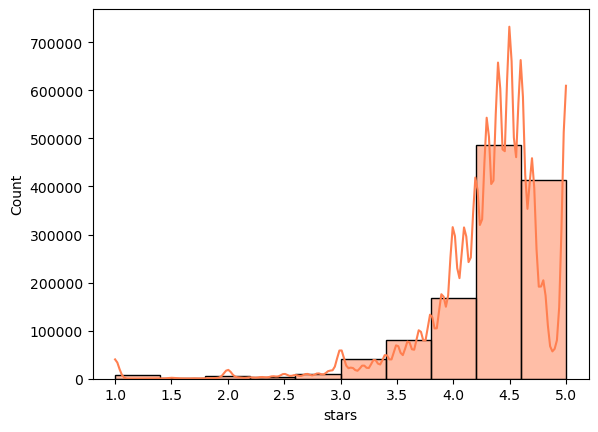

In [109]:
valids_ratings = df[df["stars"] > 0]["stars"]

sns.histplot(valids_ratings, bins=10, kde=True, color='coral')
plt.show()

In [ ]:
##The 4.5 rating is the most common.